In [1]:
import os 
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch 
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
from omegaconf import OmegaConf
import torch 
import numpy as np
import random
from compo_predictive_learning.models import create_model
import hydra
import logging
from collections import defaultdict
from compo_predictive_learning.datasets import make_sketch_dataloaders
logger = logging.getLogger(__name__)


In [2]:

def set_seed(seed=0):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

np.set_printoptions(precision=5, suppress=True, linewidth=200)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [3]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose

with initialize_config_dir(version_base=None, config_dir="/home/ghb24/paper_git/er/comp_predictive_learning/scripts/configs"):
    config = compose(config_name="train_rnn.yaml")


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'train_rnn.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
set_seed(config.seed)   
pretrain_loader,val_loader, smaller_pretrain_loader,analysis_loader,classification_metric_train_loaders, classification_metric_val_loaders,latent_names, train_contexts,val_contexts = make_sketch_dataloaders(config)

all_contexts = train_contexts + val_contexts

model = create_model(config).to(DEVICE)


Found a good split after 1 tries.


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/torch/utils/data/sampler.py:76: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


Output shape from conv layers 1024


In [5]:
    

# print(model)
# optimizer = torch.optim.AdamW(model.parameters(),lr=config.train_loop.pretrain_lr,weight_decay=config.train_loop.pretrain_decay)

# logger.info("-----------------")
# logger.info("Pretraining")
# logger.info("-----------------")

# metrics = defaultdict(list)

# logging_groups =  {}
    
# model,training_losses, validation_losses, metrics = train_loop(config,
#                                                             pretrain_loader,
#                                                             val_loader,
#                                                             smaller_pretrain_loader,
#                                                             analysis_loader,
#                                                             model,
#                                                             optimizer,
#                                                             all_contexts,
#                                                             latent_names,
#                                                             classification_metric_train_loaders,
#                                                             classification_metric_val_loaders,
#                                                             logger=print)
    


In [6]:
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_256_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/revieww/contextual_full_1_0.8/sketch_6/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2, 3, 4, 5]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))
# model.load_state_dict(torch.load("/home/ghb24/comp_predictive_learning/test/contextual_full_1_0.8/sketch_6_4/['white', 'red', 'green', 'blue']/[1]/False/[1]_512_128_128_64_16/['next_primitive_offset', 'next_color_offset', 'next_position_offset', 'next_scale_offset']/[0, 1, 2]/[0]/[0, 1, 2]/[0, 1, 2]/ae_pred/conv_[16, 16, 16]_relu_none_False_512/rnn_512_relu_1_False_eye_0.05/conv_[16, 16, 16]_relu_none/True/5000_0.001_0.001_0.01_0_0_128/seed0/model_step_4999.pth"))

/tmp/ipykernel_2937479/1067281426.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home/ghb24/paper_git/er/comp_predictive_learning/rev

<All keys matched successfully>

Output shape from conv layers 1024
Optimal number of clusters: 13, Silhouette scores: [0.12488 0.10612 0.11349 0.13635 0.16305 0.18261 0.21426 0.23715 0.25243 0.26929 0.26379 0.27214 0.26215 0.25745 0.25869 0.25996 0.26111 0.25964 0.25303 0.25467 0.26108 0.25969 0.25388]


(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Neuron Clusters', ylabel='Contexts'>)

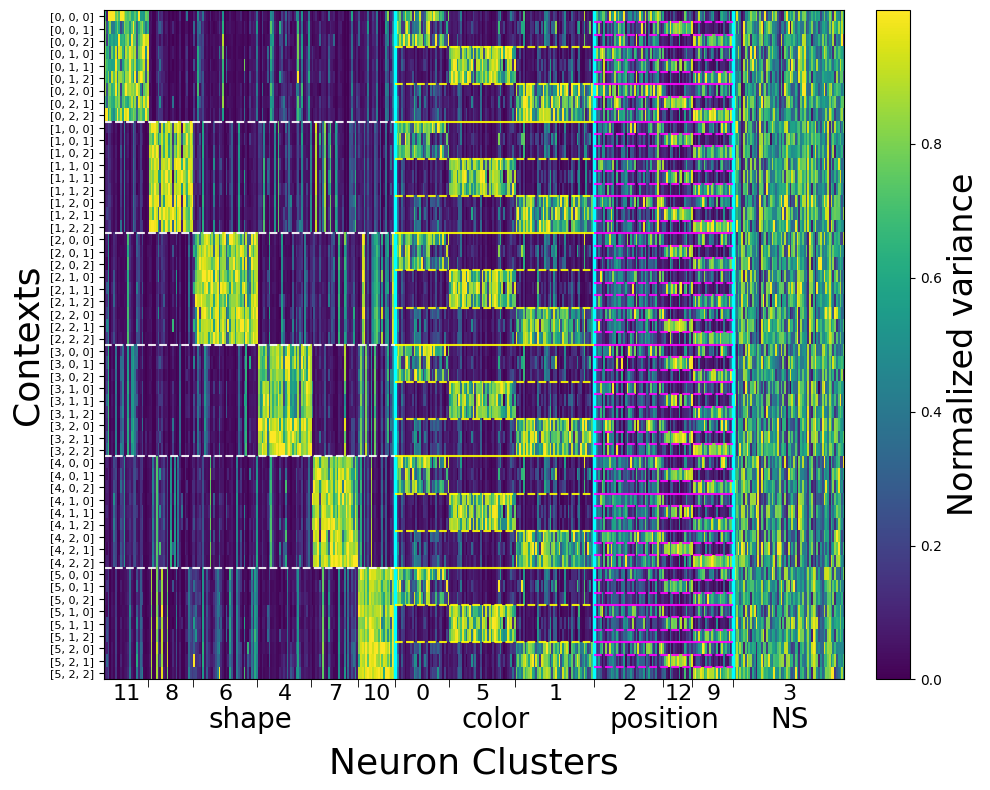

In [7]:
import matplotlib.pyplot as plt
from comp_predictive_learning.metrics.clustering import get_rnn_activities_and_sources_for_loader_for_clustering, get_optimal_n_cluster, analyze_and_sort_clusters, plot_sequentially_sorted_clusters

activations, contexts = get_rnn_activities_and_sources_for_loader_for_clustering(model, analysis_loader)
max_num_clusters, scores, norm_var_activities_per_context, active_units, labels = get_optimal_n_cluster(model, activations=activations, contexts=contexts, time_variance=False, device=DEVICE)
unique_contexts, inv = contexts.unique(dim=0, return_inverse=True)

print(f"Optimal number of clusters: {max_num_clusters}, Silhouette scores: {scores}")

(sorted_order, group_labels, group_boundaries,
peak_map, informative_indices, cluster_profiles) = analyze_and_sort_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    selectivity_threshold= 0.2,
    purity_threshold= 0.5
)
fig_cluster,ax_cluster = plt.subplots(1, 1, figsize=(10, 8))

plot_sequentially_sorted_clusters(
    norm_var_activities_per_context=norm_var_activities_per_context.cpu().numpy(),
    contexts_unique=unique_contexts.cpu(),
    labels=labels,
    final_cluster_order=sorted_order,
    group_labels=group_labels,
    group_boundaries_by_cluster_count=group_boundaries,
    group_name_map={"C0":"shape","C1":"color","C2":"position"},
    put_y_label= not "auto" in config.model.type,
    fig=fig_cluster,
    ax=ax_cluster
)


Output shape from conv layers 1024
Output shape from conv layers 1024
Cluster 0, original loss: 0.0003, new loss: 0.0017
Output shape from conv layers 1024
Cluster 1, original loss: 0.0003, new loss: 0.0022
Output shape from conv layers 1024
Cluster 2, original loss: 0.0003, new loss: 0.0005
Output shape from conv layers 1024
Cluster 3, original loss: 0.0003, new loss: 0.0034
Output shape from conv layers 1024
Cluster 4, original loss: 0.0003, new loss: 0.0010
Output shape from conv layers 1024
Cluster 5, original loss: 0.0003, new loss: 0.0023
Output shape from conv layers 1024
Cluster 6, original loss: 0.0003, new loss: 0.0011
Output shape from conv layers 1024
Cluster 7, original loss: 0.0003, new loss: 0.0007
Output shape from conv layers 1024
Cluster 8, original loss: 0.0003, new loss: 0.0009
Output shape from conv layers 1024
Cluster 9, original loss: 0.0003, new loss: 0.0013
Output shape from conv layers 1024
Cluster 10, original loss: 0.0003, new loss: 0.0009
Output shape from 

(<Figure size 1000x800 with 2 Axes>,
 <Axes: xlabel='Lesioned cluster', ylabel='Contexts'>)

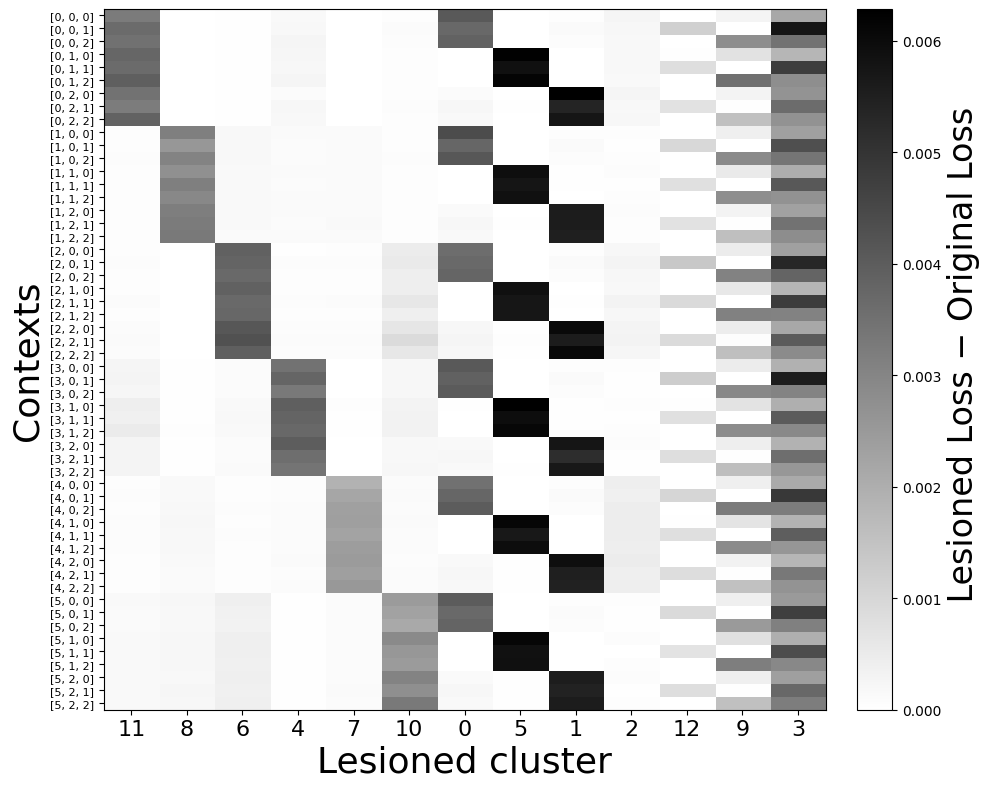

In [8]:
from comp_predictive_learning.metrics.clustering import computer_lesioned_cluster_losses,plot_cluster_lesion_delta

fig_lesion,ax_lesion = plt.subplots(1, 1, figsize=(10, 8))
cluster_losses, original_network_losses,cluster_to_neurons = computer_lesioned_cluster_losses(model,
                                                                        dataloader=analysis_loader,
                                                                        active_units=active_units,
                                                                        labels=labels,
                                                                        number_of_clusters=max_num_clusters)

plot_cluster_lesion_delta(
    original_network_losses=original_network_losses,
    lesioned_cluster_loss=cluster_losses,
    cluster_order=sorted_order, 
    put_y_label= not "auto" in config.model.type,
    fig=fig_lesion,
    ax=ax_lesion)



In [8]:
original_indices = np.where(active_units)[0]
cluster_to_neurons = {}
for i, cluster_id in enumerate(np.unique(labels)):
    neurons_in_cluster_mask = labels == cluster_id
    cluster_to_neurons[cluster_id] = original_indices[neurons_in_cluster_mask]

all_neurons_groups = {}
for k in cluster_to_neurons:
    all_neurons_groups[str(k)] = cluster_to_neurons[k]

for k in all_neurons_groups:
    print(f"Group {k} has {(all_neurons_groups[k])} neurons")
    
context_to_cluster = {}
curr_idx = 0
for i, gl in enumerate(group_labels):
    context_to_cluster[gl] = []
    for k in range(curr_idx, group_boundaries[i]):
        context_to_cluster[gl].append(sorted_order[k])
    curr_idx = group_boundaries[i]

context_to_neurons = {}
for gl in context_to_cluster:
    context_to_neurons[gl] = []
    for c in context_to_cluster[gl]:
        context_to_neurons[gl] += list(cluster_to_neurons[c])
    context_to_neurons[gl] = np.unique(context_to_neurons[gl])

latent_keys = list(context_to_cluster.keys())

Group 0 has [ 16  64  83  86 104 119 143 169 174 248 282 283 285 304 306 313 316 317 330 343 358 378 397 426 440 445 466 481 482 496] neurons
Group 1 has [  7  14  25  45  62  69  97  98 109 117 134 137 142 145 160 167 168 189 201 208 212 214 234 237 259 264 276 277 289 293 303 320 324 351 376 383 390 411 433 441 446 448 460 501] neurons
Group 2 has [ 10  21  36  48  50  81  90 126 150 153 163 173 176 179 192 205 223 232 243 266 279 309 328 332 336 357 393 413 415 428 437 452 459 470 472 479 488 497 504] neurons
Group 3 has [  2   4  11  12  40  41  75  79  92  95 103 128 129 146 155 166 180 188 206 207 210 221 233 246 251 255 260 262 265 267 273 275 281 288 299 329 338 341 342 346 347 348 352 354 360 363 400 423 424
 429 436 439 449 455 464 468 476 477 483 494 506 507] neurons
Group 4 has [  8  30  33  44  60 121 130 138 178 184 190 200 202 235 236 253 263 305 308 334 339 369 380 382 386 407 416 419 489 499] neurons
Group 5 has [ 20  24  42  77  87  94 112 113 122 144 147 157 196 227 

In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def get_activities_for_latent_dynamic(
    latent_idx,
    dynamic_idx,
    dataloader,
    model,
    context_to_cluster,
    cluster_to_neurons,
    device='cuda'
):
    
    # --- 1. Neuron Selection Logic ---
    latent_keys = list(context_to_cluster.keys())
    target_latent_key = latent_keys[latent_idx]
    
    # Get cluster and neurons
    target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
    neuron_indices = cluster_to_neurons[target_cluster_id]
    

    # --- 2. Data Collection ---
    collected_activities = []
    collected_latents = []
    
    model.eval()
    
    with torch.no_grad():
        i = 0
        for batch in dataloader:
            inputs, latents, context = batch
            inputs = inputs.to(device)
            latents = torch.cat((latents[:,:,:1],latents[:,:,2:]), dim=2).to(device)  # Ensure latents is on the same device
            batch_dynamic_indices = context[:, latent_idx]
            mask = (batch_dynamic_indices == dynamic_idx)
            if mask.sum() == 0:
                print("No sequences found for this dynamic in the current batch, skipping...")
                continue

            rnn_act = model(inputs)[2].permute(1, 0, 2)
            
            print(context.shape,latents.shape)
            latents = latents.permute(1, 0, 2)  # (B, T, Latents)
            filtered_acts = rnn_act[mask]       
            filtered_latents = latents[mask]    
            relevant_acts = filtered_acts[:, :, neuron_indices] 
            
            collected_activities.append(relevant_acts.cpu().numpy())
            collected_latents.append(filtered_latents.cpu().numpy())

    if not collected_activities:
        print("No sequences found.")
        return

    # Concatenate
    X = np.concatenate(collected_activities, axis=0) # (Total_Seq, Time, Neurons)
    L = np.concatenate(collected_latents, axis=0)    # (Total_Seq, Time, Latents)
    return X, L, target_latent_key, target_cluster_id, neuron_indices

def project_trajectories(
    X,
    L,
    projection_strategy,
    start_from_second_activity=False,
):
    
    if start_from_second_activity:
        X = X[:,1:]
        L = L[:,1:]
    B, T, D = X.shape
    X_flat = X.reshape(B * T, D)
    
    print(f"Projecting {B} sequences...")
    X_proj_flat = projection_strategy.fit_transform(X_flat)
    X_proj = X_proj_flat.reshape(B, T, 2)

    return X_proj



In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap,MDS

class TrajectoryProjector:
    """Base class for projection strategies."""
    def fit_transform(self, data):
        """
        Args:
            data: Numpy array of shape (Batch * Time, Neurons)
        Returns:
            Projected data of shape (Batch * Time, 2)
        """
        raise NotImplementedError

class PCAProjector(TrajectoryProjector):
    def fit_transform(self, data):
        pca = PCA(n_components=5)
        pca.fit(data)
        print(f"PCA explained variance ratios: {pca.explained_variance_ratio_}")
        return pca.fit_transform(data)[:, 1:3]  # Take top 2 components for visualization

class IsomapProjector(TrajectoryProjector):
    def __init__(self, n_neighbors=15):
        self.n_neighbors = n_neighbors

    def fit_transform(self, data):
        # Isomap can be slow on large datasets; consider subsampling if needed
        iso = Isomap(n_components=2, n_neighbors=self.n_neighbors)
        return iso.fit_transform(data)

class TSNEProjector(TrajectoryProjector):
    def fit_transform(self, data):
        tsne = TSNE(n_components=2, init='pca', learning_rate='auto')
        return tsne.fit_transform(data)

class MDSProjector(TrajectoryProjector):
    def fit_transform(self, data):
        mds = MDS(n_components=2, random_state=42)
        return mds.fit_transform(data)

class UMAPProjector(TrajectoryProjector):
    def __init__(self, n_neighbors=5, min_dist=0.1):
        self.n_neighbors = n_neighbors
        self.min_dist = min_dist

    def fit_transform(self, data):
        import umap
        reducer = umap.UMAP(n_neighbors=self.n_neighbors, min_dist=self.min_dist)
        return reducer.fit_transform(data)

    

In [11]:
from matplotlib.lines import Line2D

def plot_trajectories_with_latent_values(
    X_proj,
    L,
    latent_idx,
    num_initial_conditions_to_plot=-1,
    title='',
    annotate=True,
    annotate_every=1,
    annotate_offset=(0.0, 0.0),
    use_mean=False,
    filename=None,
    legend_fontsize=16,
    label_fontsize=14,
    title_fontsize=16,
    annotation_fontsize=12,
):
    fig, ax = plt.subplots(figsize=(12, 9))

    # Build the trajectories to plot here
    X_plot_list = []
    L_plot_list = []
    plotted_vals = []
    initial_values = L[:, 0, latent_idx]
    unique_vals = np.unique(initial_values)
    for val in unique_vals:
        mask = (initial_values == val)

        if not np.any(mask):
            continue

        if use_mean:
            X_plot_list.append(np.mean(X_proj[mask], axis=0))
            L_plot_list.append(np.mean(L[mask], axis=0))
        else:
            first_idx = np.where(mask)[0][0]
            X_plot_list.append(X_proj[first_idx])
            L_plot_list.append(L[first_idx])

        plotted_vals.append(val)

    X_plot = np.stack(X_plot_list)
    L_plot = np.stack(L_plot_list)
    plotted_vals = np.array(plotted_vals)

    # How many to plot
    n_total = len(plotted_vals)
    n_plot = (
        min(n_total, num_initial_conditions_to_plot)
        if num_initial_conditions_to_plot and num_initial_conditions_to_plot > 0
        else n_total
    )

    cmap = cm.viridis
    colors = cmap(np.linspace(0, 1, n_plot))

    ax.set_facecolor("white")
    ax.grid(True, alpha=0.25, linewidth=0.8)

    for i in range(n_plot):
        x_traj = X_plot[i, :, 0]
        y_traj = X_plot[i, :, 1]
        traj_latent_values = L_plot[i, :, latent_idx]

        init_val = plotted_vals[i]
        color = colors[i]

        # Line
        ax.plot(x_traj, y_traj, color=color, alpha=0.75, linewidth=2)

        # Points
        ax.scatter(x_traj, y_traj, color=color, s=18, alpha=0.35, linewidths=0)

        # Start marker
        ax.scatter(
            x_traj[0], y_traj[0],
            marker="^", s=70,
            facecolor=color, edgecolor="black", linewidth=0.8,
            zorder=5
        )

        # End marker
        ax.scatter(
            x_traj[-1], y_traj[-1],
            marker="s", s=70,
            facecolor=color, edgecolor="black", linewidth=0.8,
            zorder=5
        )

        # Legend entry for trajectory color
        ax.plot([], [], color=color, linewidth=3, label=f"{int(init_val)}")

        if annotate:
            dx, dy = annotate_offset
            for t in range(0, len(x_traj), max(1, int(annotate_every))):
                ax.text(
                    x_traj[t] + dx,
                    y_traj[t] + dy,
                    f"{int(traj_latent_values[t])}",
                    fontsize=annotation_fontsize,
                    alpha=0.85,
                    color="black",
                    ha="center",
                    va="bottom"
                )

    ax.set_title(title, fontsize=title_fontsize, pad=12)
    ax.set_xlabel("MDS Dimension 1", fontsize=label_fontsize)
    ax.set_ylabel("MDS Dimension 2", fontsize=label_fontsize)
    ax.margins(0.05)

    # Existing trajectory handles
    traj_handles, traj_labels = ax.get_legend_handles_labels()

    # Custom marker legend handles
    marker_handles = [
        Line2D(
            [0], [0],
            marker="^",
            color="none",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markersize=9,
            linestyle="None",
            label="Start"
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor="lightgray",
            markeredgecolor="black",
            markersize=9,
            linestyle="None",
            label="End"
        ),
    ]

    leg = ax.legend(
        handles=traj_handles + marker_handles,
        title=f"Initial Latent Value \n(Latent {latent_idx})",
        loc="best",
        fontsize=legend_fontsize,
        title_fontsize=legend_fontsize,
        frameon=True,
        framealpha=0.9
    )
    leg.get_frame().set_linewidth(0.0)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

In [13]:
def plot_sequence_pipeline(model,
                           loader,
                           latent_idx,
                           dynamic_idx,
                           context_to_cluster,
                           cluster_to_neurons,
                           latent_keys,
                           projection_strategy,
                           title,
                           filename=None,
                           initial_conditions_to_show=3):
    
    latent_keys = list(context_to_cluster.keys())
    target_latent_key = latent_keys[latent_idx]

    # Get cluster and neurons
    target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
    neuron_indices = cluster_to_neurons[target_cluster_id]

    print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
    print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")

    X, L, target_latent_key, target_cluster_id, neuron_indices = get_activities_for_latent_dynamic(
        latent_idx=latent_idx,
        dynamic_idx=dynamic_idx,
        dataloader=loader,
        model=model,
        context_to_cluster=context_to_cluster,
        cluster_to_neurons=cluster_to_neurons,
        device=DEVICE
    )    
    
    X_proj = project_trajectories(
        X=X,
        L=L,
        projection_strategy=projection_strategy,
        start_from_second_activity=False,
    )
    
    plot_trajectories_with_latent_values(
        X_proj=X_proj,
        L=L,
        latent_idx=latent_idx,
        title=title,
        use_mean=False,   # or True
        num_initial_conditions_to_plot=initial_conditions_to_show,
        filename=filename,
        legend_fontsize = 20,
        label_fontsize = 18,
        title_fontsize = 20,
        annotation_fontsize = 16
    )
    

In [16]:
from compo_predictive_learning.datasets import make_contextual_loader
all_contexts = train_contexts + val_contexts 
config.dataset.sequence_length = 10
config.train_loop.batch_size = 32
analysis_loader = make_contextual_loader(config=config,context_vals=all_contexts,num_sample_per_context=32,context_vector_size=3,context_start_idx=0,shuffle=False)

from copy import deepcopy
rnn_cfg = deepcopy(model.rnn_cfg)
rnn_cfg.noise = 0.0
noiseless_model = model.create_new_instance(new_params={'rnn_cfg': rnn_cfg}).to(DEVICE)


Output shape from conv layers 1024


In [14]:
from compo_predictive_learning.datasets import make_contextual_loader
all_contexts = train_contexts + val_contexts 
config.dataset.sequence_length = 10
config.train_loop.batch_size = 32
analysis_loader = make_contextual_loader(config=config,context_vals=all_contexts,num_sample_per_context=32,context_vector_size=3,context_start_idx=0,shuffle=False)

from copy import deepcopy
rnn_cfg = deepcopy(model.rnn_cfg)
rnn_cfg.noise = 0.0
noiseless_model = model.create_new_instance(new_params={'rnn_cfg': rnn_cfg}).to(DEVICE)


Output shape from conv layers 1024


Analyzing Latent: 'C0' (Idx 0) | Dynamic: 3
Cluster ID: 4 | Neurons: 30
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for thi

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


ValueError: Unknown format code 'i' for object of type 'float'

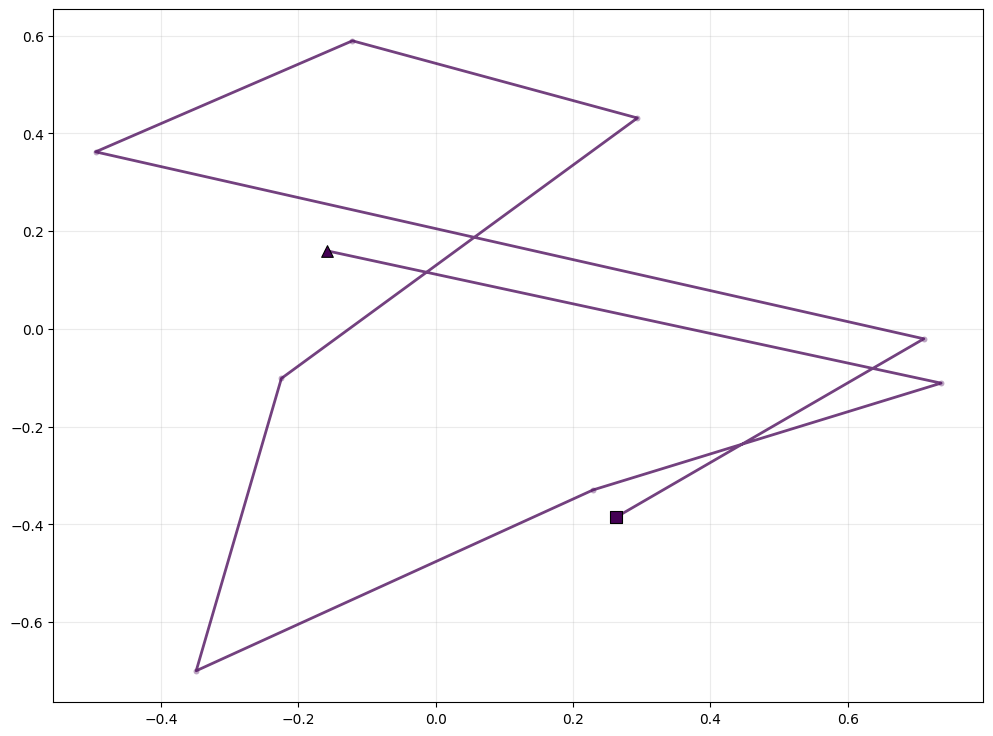

In [ ]:

latent_idx = 0
dynamic_idx = 3

latent_keys = list(context_to_cluster.keys())
target_latent_key = latent_keys[latent_idx]

# Get cluster and neurons
target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
neuron_indices = cluster_to_neurons[target_cluster_id]

print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")


X, L, target_latent_key, target_cluster_id, neuron_indices = get_activities_for_latent_dynamic(
    latent_idx=latent_idx,
    dynamic_idx=dynamic_idx,
    dataloader=analysis_loader,
    model=noiseless_model,
    context_to_cluster=context_to_cluster,
    cluster_to_neurons=cluster_to_neurons,
    device=DEVICE
)

X_proj = project_trajectories(
    X, L, MDSProjector(), start_from_second_activity=False,
)



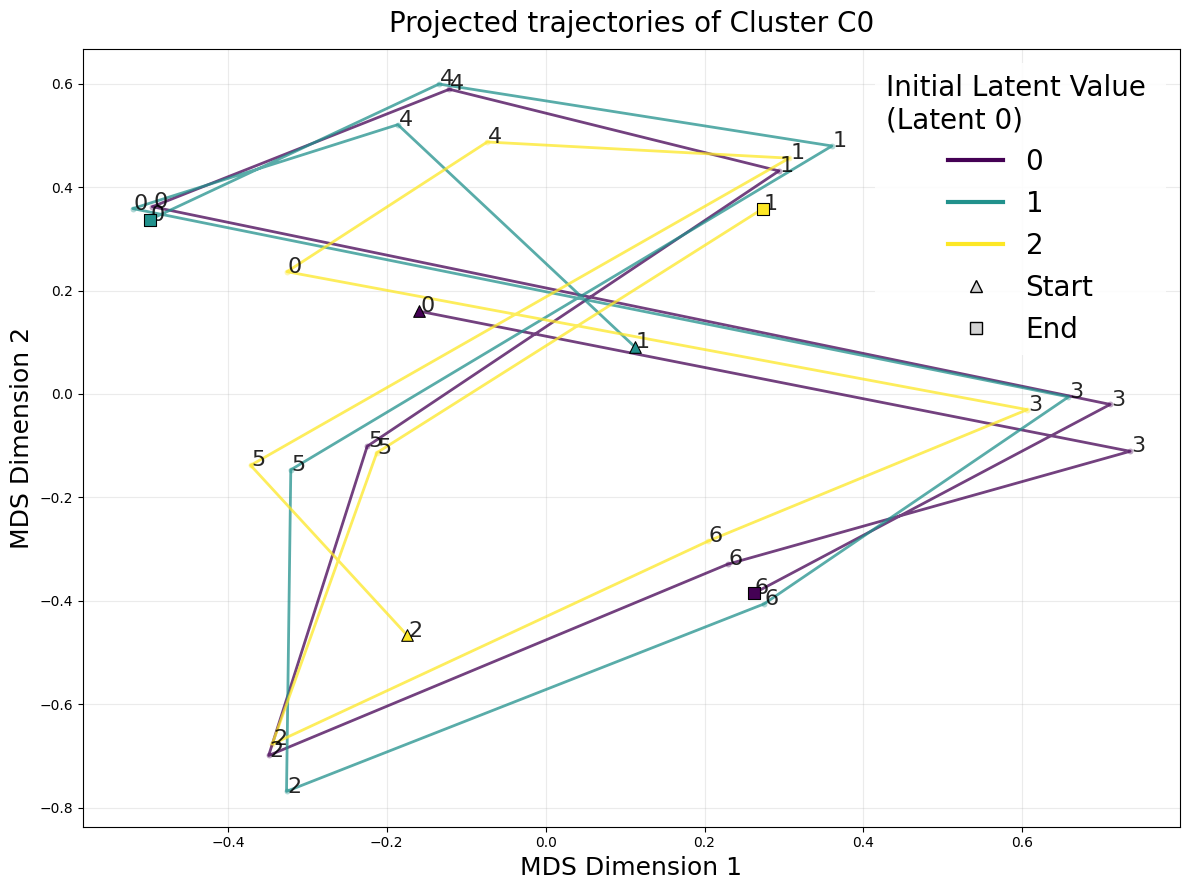

In [31]:

plot_trajectories_with_latent_values(
    X_proj,
    L,
    latent_idx,
    title="Projected trajectories of Cluster C0",
    use_mean=False,   # or False
    num_initial_conditions_to_plot=3,
    annotate_offset=(0.01, -0.01),
    legend_fontsize = 20,
    label_fontsize = 18,
    title_fontsize = 20,
    annotation_fontsize = 16

)

In [ ]:

# latent_idx = 1
# dynamic_idx = 0

# latent_keys = list(context_to_cluster.keys())
# target_latent_key = latent_keys[latent_idx]

# # Get cluster and neurons
# target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
# neuron_indices = cluster_to_neurons[target_cluster_id]

# print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
# print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")


# X, L, target_latent_key, target_cluster_id, neuron_indices = get_activities_for_latent_dynamic(
#     latent_idx=latent_idx,
#     dynamic_idx=dynamic_idx,
#     dataloader=analysis_loader,
#     model=noiseless_model,
#     context_to_cluster=context_to_cluster,
#     cluster_to_neurons=cluster_to_neurons,
#     device=DEVICE
# )

# X_proj = project_trajectories(
#     X, L, MDSProjector(), start_from_second_activity=False,
# )


# plot_trajectories_with_latent_values(
#     X_proj,
#     L,
#     latent_idx,
#     title="Projected trajectories of Cluster C0",
#     use_mean=False,   # or False
#     num_initial_conditions_to_plot=3
# )

Projecting 576 sequences...


/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Analyzing Latent: 'C0' (Idx 0) | Dynamic: 3
Cluster ID: 4 | Neurons: 30
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for thi

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


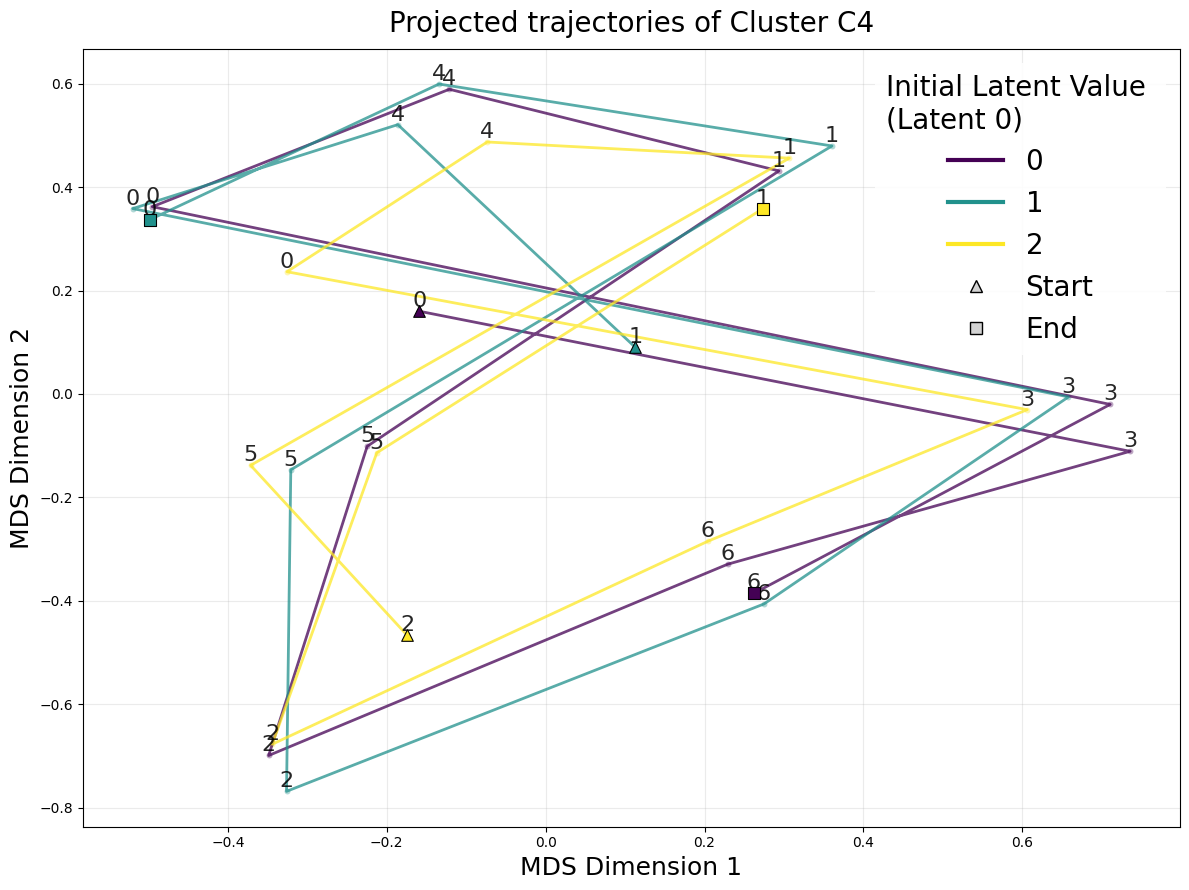

In [33]:
plot_sequence_pipeline(model=noiseless_model,
                       loader=analysis_loader,
                       latent_idx=0,
                       dynamic_idx=3,
                       context_to_cluster=context_to_cluster,
                       cluster_to_neurons=cluster_to_neurons,
                       latent_keys=latent_keys,
                       projection_strategy=MDSProjector(),
                       title="Projected trajectories of Cluster C4",
                       filename="cluster_c4_trajectories.pdf")

Analyzing Latent: 'C1' (Idx 1) | Dynamic: 0
Cluster ID: 0 | Neurons: 30
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No sequences found for this dynamic in the current batch, skipping...
No sequences found for this dynamic in the current batch, skipping...
torch.Size([32, 4]) torch.Size([10, 32, 3])
No seque

/home/ghb24/miniconda3/envs/pre/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


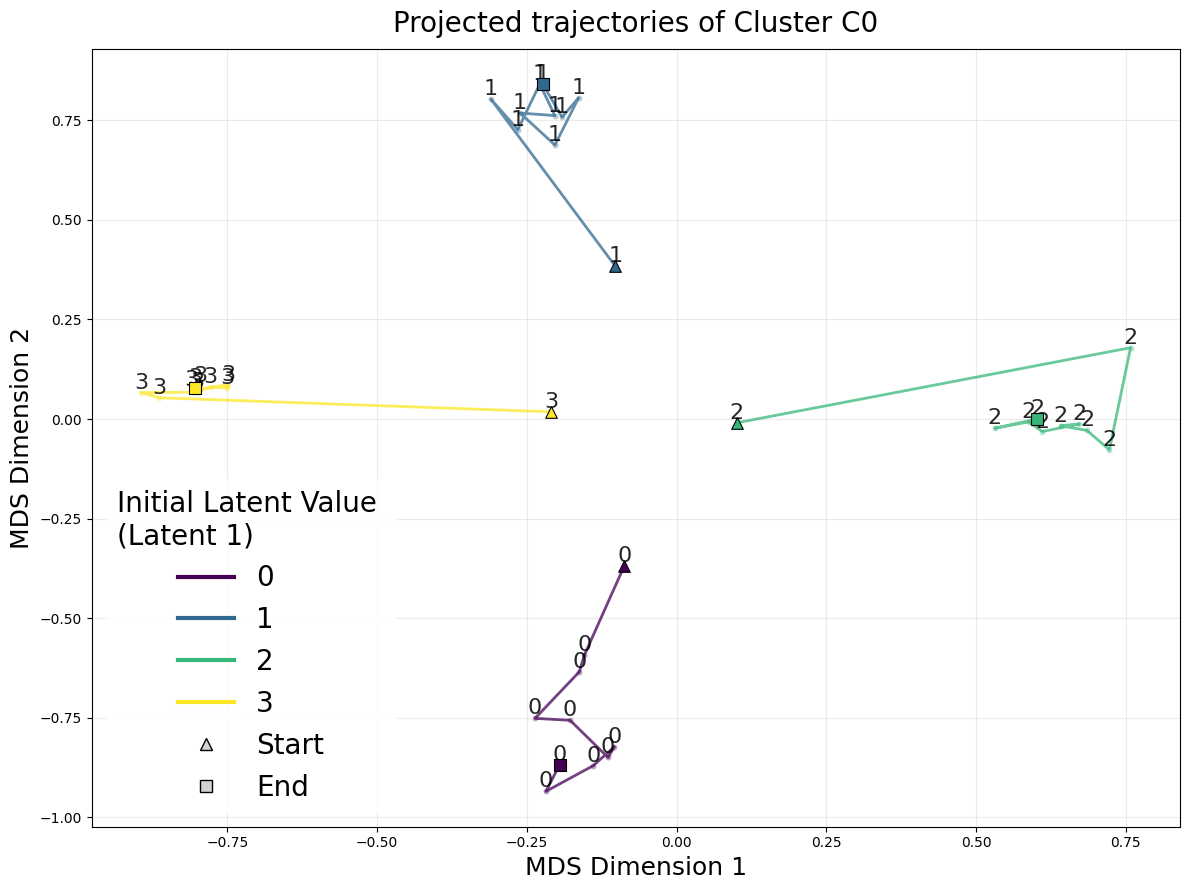

In [37]:
plot_sequence_pipeline(model=noiseless_model,
                       loader=analysis_loader,
                       latent_idx=1,
                       dynamic_idx=0,
                       context_to_cluster=context_to_cluster,
                       cluster_to_neurons=cluster_to_neurons,
                       latent_keys=latent_keys,
                       projection_strategy=MDSProjector(),
                       title="Projected trajectories of Cluster C0",
                       filename="cluster_c0_trajectories.pdf",
                       initial_conditions_to_show=4)


In [ ]:
import torch
from collections import defaultdict

@torch.no_grad()
def decompose_rnn_dynamics(rnn_layer, rnn_inputs):
    """
    rnn_inputs: (T, B, input_dim) = the sequence fed directly into JitLeakyRNNLayer
    returns tensors of shape (T, B, hidden_dim)
    """
    T, B, _ = rnn_inputs.shape
    device = rnn_inputs.device

    state = torch.zeros(B, rnn_layer.hidden_dim, device=device)
    out_prev = torch.zeros_like(state)

    out = defaultdict(list)

    for t in range(T):
        I_in = rnn_layer.alpha * rnn_layer.input_layer(rnn_inputs[t])
        I_rec = rnn_layer.alpha * rnn_layer.weight_hh(out_prev)
        I_leak = -state
        net = I_in + I_rec + I_leak
        net_without_input = rnn_layer.alpha * I_rec + I_leak
        new_state = state + rnn_layer.alpha * net
        new_out = rnn_layer.activation(new_state)

        out["state_before"].append(state.clone())
        out["input_current"].append(I_in.clone())
        out["recurrent_current"].append(I_rec.clone())
        out["leak_current"].append(I_leak.clone())
        out["net_current"].append(net.clone())
        out["net_without_input"].append(net_without_input.clone())
        out["state_after"].append(new_state.clone())
        out["activity"].append(new_out.clone())

        state = new_state
        out_prev = new_out

    return {k: torch.stack(v, dim=0) for k, v in out.items()}


import torch
from collections import defaultdict

@torch.no_grad()
def decompose_rnn_dynamics_by_cluster(rnn_layer, rnn_inputs, cluster_to_neurons):
    """
    rnn_inputs: (T, B, input_dim)
    cluster_to_neurons: dict mapping cluster_id -> list of neuron indices
    """
    T, B, _ = rnn_inputs.shape
    device = rnn_inputs.device

    state = torch.zeros(B, rnn_layer.hidden_dim, device=device)
    out_prev = torch.zeros_like(state)

    out = defaultdict(list)
    
    # Nested dictionary to store inputs: cluster_inputs[source_id][target_id]
    cluster_inputs = {
        src: {tgt: [] for tgt in cluster_to_neurons.keys()} 
        for src in cluster_to_neurons.keys()
    }

    # Extract the full hidden-to-hidden weight matrix
    # Assumes rnn_layer.weight_hh is an nn.Linear module
    W_hh = rnn_layer.weight_hh.weight 

    print(W_hh.shape)
    for t in range(T):
        # 1. Standard Dynamics
        I_in = rnn_layer.alpha * rnn_layer.input_layer(rnn_inputs[t])
        I_rec = rnn_layer.alpha * rnn_layer.weight_hh(out_prev)
        I_leak = -state
        net = I_in + I_rec + I_leak
        net_without_input = rnn_layer.alpha * I_rec + I_leak
        new_state = state + rnn_layer.alpha * net
        new_out = rnn_layer.activation(new_state)

        for src_id, src_idx in cluster_to_neurons.items():
            # Source activity at t-1. Shape: (B, len(src_idx))
            src_activity = out_prev[:, src_idx] 
            
            for tgt_id, tgt_idx in cluster_to_neurons.items():
                # Sub-matrix of weights from Source -> Target
                # Shape: (len(tgt_idx), len(src_idx))
                print(f"Cluster {src_id} -> Cluster {tgt_id}: src neurons {len(src_idx)}, tgt neurons {len(tgt_idx)}")
                W_sub = W_hh[tgt_idx][:, src_idx]  # Extract relevant weights for this source-target pair
                
                # I_{src -> tgt} = alpha * (Activity_{src} @ W_sub^T)
                # Shape: (B, len(tgt_idx))
                I_src_to_tgt = rnn_layer.alpha * (src_activity @ W_sub.T)
                
                cluster_inputs[src_id][tgt_id].append(I_src_to_tgt.clone())

        # 3. Store Data
        out["state_before"].append(state.clone())
        out["input_current"].append(I_in.clone())
        out["recurrent_current"].append(I_rec.clone())
        out["leak_current"].append(I_leak.clone())
        out["net_current"].append(net.clone())
        out["net_without_input"].append(net_without_input.clone())
        out["state_after"].append(new_state.clone())
        out["activity"].append(new_out.clone())

        state = new_state
        out_prev = new_out

    # Stack the standard dynamics into tensors of shape (T, B, hidden_dim)
    stacked_out = {k: torch.stack(v, dim=0) for k, v in out.items()}
    
    # Stack the cluster inputs into tensors of shape (T, B, len(target_idx))
    stacked_cluster_inputs = {
        src: {
            tgt: torch.stack(cluster_inputs[src][tgt], dim=0) 
            for tgt in cluster_to_neurons.keys()
        }
        for src in cluster_to_neurons.keys()
    }
    
    # Append the cluster tracking to the output dictionary
    stacked_out["cluster_to_cluster_rec"] = stacked_cluster_inputs
    return stacked_out

In [211]:

def get_rnn_decomposed(
    latent_idx,
    dynamic_idx,
    dataloader,
    model,
    context_to_cluster,
    cluster_to_neurons,
    device='cuda'
):
    
    # --- 1. Neuron Selection Logic ---
    latent_keys = list(context_to_cluster.keys())
    target_latent_key = latent_keys[latent_idx]
    
    # Get cluster and neurons
    target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
    neuron_indices = cluster_to_neurons[target_cluster_id]
    
    print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
    print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")
    
    # --- 2. Data Collection ---
    collected_activities = []
    collected_latents = []
    
    model.eval()
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, latents, context = batch
            latents = torch.cat([latents[:,:,:1], latents[:,:,2:]], dim=2)  # remove scale info from latents
            inputs = inputs.to(device)
            
            print(f"Batch context: {context[0].cpu().numpy()}")  # Debug print to check contexts
            batch_dynamic_indices = context[:, latent_idx]
            mask = (batch_dynamic_indices == dynamic_idx)
            
            if mask.sum() == 0:
                print("No sequences found for this dynamic in the current batch, skipping...")
                continue
            
            rnn_inputs = model.encoder(inputs)  # (T, B, input_dim)
            rnn_decomposed = decompose_rnn_dynamics_by_cluster(model.rnn, rnn_inputs, cluster_to_neurons)
            decomposed_by_latents_cluster = {}
            for cluster_id in context_to_cluster[target_latent_key]:
                cluster_neurons = cluster_to_neurons[cluster_id]
                decomposed_by_latents_cluster[cluster_id] = {
                    k: v[:, :, cluster_neurons] for k, v in rnn_decomposed.items() if k != "cluster_to_cluster_rec"
                }
            decomposed_by_latents_cluster["cluster_to_cluster_rec"] = rnn_decomposed["cluster_to_cluster_rec"]
            latents = latents.permute(1, 0, 2)  # (B, T, Latents)
            return decomposed_by_latents_cluster


In [212]:
latent_idx = 0
dynamic_idx = 3
decomposed = get_rnn_decomposed(
    latent_idx=latent_idx,
    dynamic_idx=dynamic_idx,
    dataloader=analysis_loader,
    model=noiseless_model,
    context_to_cluster=context_to_cluster,
    cluster_to_neurons=cluster_to_neurons)

Analyzing Latent: 'C0' (Idx 0) | Dynamic: 3
Cluster ID: 4 | Neurons: 30
Batch context: [3. 0. 2. 0.]
torch.Size([512, 512])
Cluster 0 -> Cluster 0: src neurons 30, tgt neurons 30
Cluster 0 -> Cluster 1: src neurons 30, tgt neurons 44


IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [44], [30]

In [162]:
decomposed.keys()

dict_keys([np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(7), np.int64(10), 'cluster_to_cluster_rec'])

In [177]:
def cosine_similarity(a, b):
    a_norm = a / (a.norm(dim=-1, keepdim=True) + 1e-8)
    b_norm = b / (b.norm(dim=-1, keepdim=True) + 1e-8)
    return (a_norm * b_norm).sum(dim=-1).mean()

cos_between_input_and_state = {}
num_negative_rec_input = {}
for cluster_id, decomp in decomposed.items():
    if cluster_id == "cluster_to_cluster_rec":
        continue
    cos_between_input_and_state[cluster_id] = []
    num_negative_rec_input[cluster_id] = []
    for t in range(6):#decomp["input_current"].shape[0]
        mask = decomp["input_current"][t, :, :] > 0
        mask = torch.ones_like(mask, dtype=torch.bool)  # consider all neurons in the cluster, not just those with positive input
        I_in = decomp["input_current"][t, :, :][mask]#.reshape(-1)
        state = decomp["recurrent_current"][t, :, :][mask] #.reshape(-1) net_without_input,recurrent_current
        self_rec = decomposed["cluster_to_cluster_rec"][cluster_id][cluster_id][t, :, :][mask]
        cos = cosine_similarity(I_in, self_rec)
        # cos = np.corrcoef(I_in.cpu().numpy(), self_rec.cpu().numpy())[0, 1]
        # cos = (I_in + state).mean()
        
        cos_between_input_and_state[cluster_id].append(cos.item())
        num_negative_rec_input[cluster_id].append((decomp["input_current"][t, :, :]).float().mean().item())
        

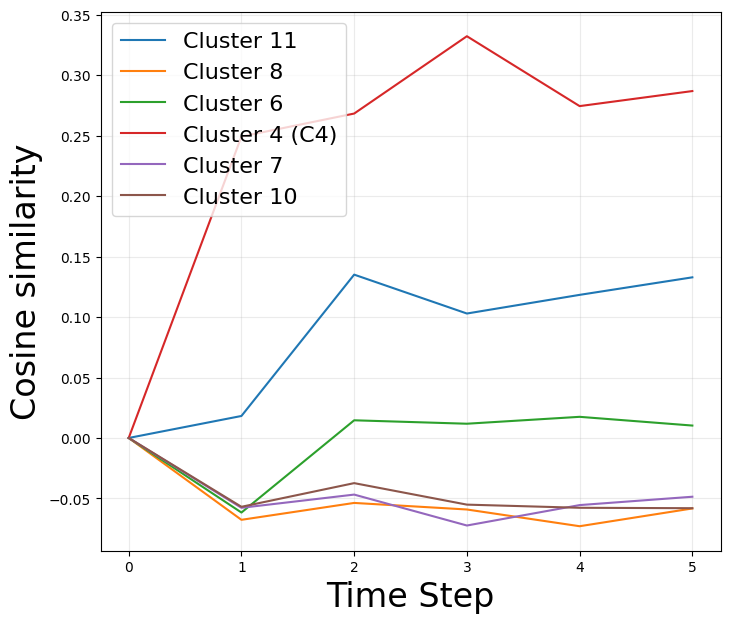

In [ ]:
fig,ax = plt.subplots(figsize=(8,7))
for cluster_id, cos_values in cos_between_input_and_state.items():
    ax.plot(cos_values, label=f"Cluster {cluster_id} {'(C4)' if cluster_id == 4 else ''}")
ax.set_xlabel("Time Step",fontsize=24)
ax.grid(True, alpha=0.25)
ax.set_facecolor("white")
ax.set_ylabel("Cosine similarity",fontsize=24)
# ax.set_title("Cosine similarity between input and recurrent current")
ax.legend(fontsize=16)
plt.show()
fig.savefig("cosine_similarity_over_time.pdf", dpi=300, bbox_inches='tight')



In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

def plot_cluster_to_cluster_heatmaps(model, decomposed_by_latents_cluster, cluster_to_neurons, T_max=None):
    """
    Plots heatmaps of the average recurrent input from source clusters to target clusters.
    One heatmap per timestep.
    """
    cluster_ids = list(decomposed_by_latents_cluster.keys())
    num_clusters = len(cluster_ids)
    
    # Get sequence length T and batch size B from the first cluster's activity
    sample_activity = decomposed_by_latents_cluster[cluster_ids[0]]['activity']
    T, B, _ = sample_activity.shape
    if T_max is not None:
        T = min(T, T_max)
        
    # Extract weight matrix and alpha from the model
    # (Assumes model.rnn.weight_hh is an nn.Linear or similar module)
    try:
        W = model.rnn.weight_hh.weight.detach() # Shape: (hidden_dim, hidden_dim)
        alpha = model.rnn.alpha.item() if isinstance(model.rnn.alpha, torch.Tensor) else model.rnn.alpha
    except AttributeError:
        raise ValueError("Could not access model.rnn.weight_hh.weight or model.rnn.alpha")
        
    # Array to hold the interaction matrices: (T, Target, Source)
    interaction_matrices = np.zeros((T, num_clusters, num_clusters))
    
    for t in range(T):
        for i, target_c in enumerate(cluster_ids):
            target_idx = cluster_to_neurons[target_c]
            
            for j, source_c in enumerate(cluster_ids):
                source_idx = cluster_to_neurons[source_c]
                
                # Sub-matrix of weights from Source to Target -> Shape: (len(target), len(source))
                W_sub = W[target_idx][:, source_idx]
                
                # Get source activity at t-1 (at t=0, recurrent input is 0)
                if t == 0:
                    src_act = torch.zeros(B, len(source_idx), device=W.device)
                else:
                    src_act = decomposed_by_latents_cluster[source_c]['activity'][t-1]
                    
                # Calculate input from source to target
                # Shape will be (Batch, len(target))
                I_src_to_tgt = alpha * (src_act.to(W.device) @ W_sub.T)
                
                # Average over the batch and over the target neurons
                interaction_matrices[t, i, j] = I_src_to_tgt.mean().item()
                
    # --- Plotting ---
    # Setup grid of subplots (e.g., max 5 columns)
    cols = min(T, 5)
    rows = (T + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if T == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Establish consistent color scale across all timesteps
    vmax = np.max(np.abs(interaction_matrices))
    if vmax == 0: vmax = 1.0 # Prevent zero-division/warning issues
    
    for t in range(T):
        ax = axes[t]
        sns.heatmap(
            interaction_matrices[t], 
            annot=True, fmt=".3f", cmap="vlag", 
            center=0, vmin=-vmax, vmax=vmax, 
            ax=ax, cbar=(t % cols == cols - 1), # Only show colorbar on the rightmost plots
            xticklabels=cluster_ids, yticklabels=cluster_ids
        )
        ax.set_title(f"Timestep {t}")
        
        # Add labels on the edges
        if t % cols == 0:
            ax.set_ylabel("Target Cluster")
        if t >= T - cols:
            ax.set_xlabel("Source Cluster")
            
    # Hide any unused subplots in the grid
    for ax in axes[T:]:
        ax.set_visible(False)
        
    plt.suptitle("Recurrent Inputs: Source Cluster $\\to$ Target Cluster", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

In [113]:
import torch
from collections import defaultdict

@torch.no_grad()
def decompose_rnn_dynamics_by_cluster(rnn_layer, rnn_inputs, cluster_to_neurons):
    """
    rnn_inputs: (T, B, input_dim)
    cluster_to_neurons: dict mapping cluster_id -> list of neuron indices
    """
    T, B, _ = rnn_inputs.shape
    device = rnn_inputs.device

    state = torch.zeros(B, rnn_layer.hidden_dim, device=device)
    out_prev = torch.zeros_like(state)

    out = defaultdict(list)
    
    # Nested dictionary to store inputs: cluster_inputs[source_id][target_id]
    cluster_inputs = {
        src: {tgt: [] for tgt in cluster_to_neurons.keys()} 
        for src in cluster_to_neurons.keys()
    }

    # Extract the full hidden-to-hidden weight matrix
    # Assumes rnn_layer.weight_hh is an nn.Linear module
    W_hh = rnn_layer.weight_hh.weight 

    for t in range(T):
        # 1. Standard Dynamics
        I_in = rnn_layer.alpha * rnn_layer.input_layer(rnn_inputs[t])
        I_rec = rnn_layer.alpha * rnn_layer.weight_hh(out_prev)
        I_leak = -state
        net = I_in + I_rec + I_leak
        net_without_input = rnn_layer.alpha * I_rec + I_leak
        new_state = state + rnn_layer.alpha * net
        new_out = rnn_layer.activation(new_state)

        # 2. Cluster-to-Cluster Recurrent Breakdown
        for src_id, src_idx in cluster_to_neurons.items():
            # Source activity at t-1. Shape: (B, len(src_idx))
            src_activity = out_prev[:, src_idx] 
            
            for tgt_id, tgt_idx in cluster_to_neurons.items():
                # Sub-matrix of weights from Source -> Target
                # Shape: (len(tgt_idx), len(src_idx))
                W_sub = W_hh[tgt_idx][:, src_idx]
                
                # I_{src -> tgt} = alpha * (Activity_{src} @ W_sub^T)
                # Shape: (B, len(tgt_idx))
                I_src_to_tgt = rnn_layer.alpha * (src_activity @ W_sub.T)
                
                cluster_inputs[src_id][tgt_id].append(I_src_to_tgt.clone())

        # 3. Store Data
        out["state_before"].append(state.clone())
        out["input_current"].append(I_in.clone())
        out["recurrent_current"].append(I_rec.clone())
        out["leak_current"].append(I_leak.clone())
        out["net_current"].append(net.clone())
        out["net_without_input"].append(net_without_input.clone())
        out["state_after"].append(new_state.clone())
        out["activity"].append(new_out.clone())

        state = new_state
        out_prev = new_out

    # Stack the standard dynamics into tensors of shape (T, B, hidden_dim)
    stacked_out = {k: torch.stack(v, dim=0) for k, v in out.items()}
    
    # Stack the cluster inputs into tensors of shape (T, B, len(target_idx))
    stacked_cluster_inputs = {
        src: {
            tgt: torch.stack(cluster_inputs[src][tgt], dim=0) 
            for tgt in cluster_to_neurons.keys()
        }
        for src in cluster_to_neurons.keys()
    }
    
    # Append the cluster tracking to the output dictionary
    stacked_out["cluster_to_cluster_rec"] = stacked_cluster_inputs
    return stacked_out

In [193]:
def get_rnn_decomposed(
    latent_idx,
    dynamic_idx,
    dataloader,
    model,
    context_to_cluster,
    cluster_to_neurons,
    device='cuda'
):
    
    # --- 1. Neuron Selection Logic ---
    latent_keys = list(context_to_cluster.keys())
    target_latent_key = latent_keys[latent_idx]
    
    target_cluster_id = context_to_cluster[target_latent_key][dynamic_idx]
    neuron_indices = cluster_to_neurons[target_cluster_id]
    
    print(f"Analyzing Latent: '{target_latent_key}' (Idx {latent_idx}) | Dynamic: {dynamic_idx}")
    print(f"Cluster ID: {target_cluster_id} | Neurons: {len(neuron_indices)}")
    
    model.eval()
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, latents, context = batch
            latents = torch.cat([latents[:,:,:1], latents[:,:,2:]], dim=2) 
            inputs = inputs.to(device)
            
            print(f"Batch context: {context[0].cpu().numpy()}")
            batch_dynamic_indices = context[:, latent_idx]
            mask = (batch_dynamic_indices == dynamic_idx)
            
            if mask.sum() == 0:
                print("No sequences found for this dynamic in the current batch, skipping...")
                continue
            
            rnn_inputs = model.encoder(inputs)  # (T, B, input_dim)
            
            # --- PASS CLUSTER INFO HERE ---
            rnn_decomposed = decompose_rnn_dynamics_by_cluster(
                model.rnn, 
                rnn_inputs, 
                cluster_to_neurons
            )
            
            decomposed_by_latents_cluster = {}

            for tg_latent in context_to_cluster.keys():
                for cluster_id in context_to_cluster[tg_latent]:
                    cluster_neurons = cluster_to_neurons[cluster_id]
                    
                    # Slicing out standard dynamics for just this cluster
                    decomposed_by_latents_cluster[cluster_id] = {
                        k: v[:, :, cluster_neurons] 
                        for k, v in rnn_decomposed.items() 
                        if k != "cluster_to_cluster_rec"
                    }
            
            # Add the cluster-to-cluster inputs back into your returned dictionary
            decomposed_by_latents_cluster["cluster_to_cluster_rec"] = rnn_decomposed["cluster_to_cluster_rec"]

            # Returning on the first valid batch
            return decomposed_by_latents_cluster

In [204]:

# 1. Get the dictionary from your function
decomposed_data = get_rnn_decomposed(
    latent_idx=0,
    dynamic_idx=3,
    dataloader=analysis_loader,
    model=model,
    context_to_cluster=context_to_cluster,
    cluster_to_neurons=cluster_to_neurons,
    device='cuda'
)


Analyzing Latent: 'C0' (Idx 0) | Dynamic: 3
Cluster ID: 4 | Neurons: 30
Batch context: [3. 0. 2. 0.]


In [205]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_champions_to_latents_single_plot(decomposed_by_latents_cluster, context_to_cluster):
    """
    Finds the champion cluster per latent and plots its mean temporal output 
    to every latent group on a single shared plot.
    """
    cluster_rec = decomposed_by_latents_cluster["cluster_to_cluster_rec"]
    latents = list(context_to_cluster.keys())
    
    # --- 1. Find the champion cluster per latent ---
    most_active_per_latent = {}
    print("--- Selecting Most Active Clusters (Champions) ---")
    print(decomposed_by_latents_cluster.keys())
    for latent, clusters in context_to_cluster.items():
        max_activity = -float('inf')
        champion_cluster = None
        
        for c in clusters:
            activity = decomposed_by_latents_cluster[np.int32(c)]['activity']
            # Mean activity over sequence, batch, and neurons
            mean_act = activity.mean().item() 
            
            if mean_act > max_activity:
                max_activity = mean_act
                champion_cluster = c
                
        most_active_per_latent[latent] = champion_cluster
        print(f"Latent '{latent}': Selected Champion Cluster {champion_cluster}")

    # --- 2. Plotting Setup ---
    plt.figure(figsize=(12, 7))
    
    # Map Source Latent to Color
    cmap = plt.get_cmap("tab10")
    src_colors = {lat: cmap(i % 10) for i, lat in enumerate(latents)}
    
    # Map Target Latent to Line Style
    # (Solid, Dashed, Dotted, Dash-Dot, loosely dashed, loosely dotted)
    styles = ['-', '--', ':', '-.', (0, (5, 5)), (0, (1, 5))]
    tgt_linestyles = {lat: styles[i % len(styles)] for i, lat in enumerate(latents)}
    
    T = None # Will store sequence length
    
    # --- 3. Extract and Plot Data ---
    for src_latent, src_champ in most_active_per_latent.items():
        print(src_latent)
        if src_latent == "Non-Selective":
            print(f"Skipping Non-Selective latent '{src_latent}'")
            continue
        for tgt_latent, tgt_clusters in context_to_cluster.items():
            
            # Gather inputs from the Champion to all clusters in the Target Latent
            tensors_to_tgt_latent = [cluster_rec[src_champ][tgt_c] for tgt_c in tgt_clusters]
            
            # Concatenate neurons to form the target latent group
            combined_target = torch.cat(tensors_to_tgt_latent, dim=2)
            
            # Average over batch (dim=1) and all target neurons (dim=2) to get a 1D sequence
            mean_over_time = combined_target.mean(dim=(1, 2)).cpu().numpy()
            
            if T is None:
                T = len(mean_over_time)
                time_steps = np.arange(T)
                
            # Plot the line
            plt.plot(
                time_steps, 
                mean_over_time, 
                color=src_colors[src_latent], 
                linestyle=tgt_linestyles[tgt_latent],
                linewidth=2,
                alpha=0.85,
                label=f"From {src_latent} $\\to$ To {tgt_latent}"
            )

    # --- 4. Formatting ---
    plt.title("Mean Current: Champion Clusters to Latent Groups Over Time", fontweight='bold', fontsize=14)
    plt.xlabel("Timestep (t)", fontsize=12)
    plt.ylabel("Average Input Strength", fontsize=12)
    plt.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    # Place legend outside the plot so it doesn't obscure the lines
    plt.legend(
        title="Connections (Source $\\to$ Target)", 
        title_fontsize='11',
        bbox_to_anchor=(1.02, 1), 
        loc='upper left', 
        ncol=1, 
        fontsize=9
    )
    
    plt.tight_layout()
    plt.show()

--- Selecting Most Active Clusters (Champions) ---
dict_keys([np.int64(11), np.int64(8), np.int64(6), np.int64(4), np.int64(7), np.int64(10), np.int64(0), np.int64(5), np.int64(1), np.int64(2), np.int64(12), np.int64(9), np.int64(3), 'cluster_to_cluster_rec'])
Latent 'C0': Selected Champion Cluster 4
Latent 'C1': Selected Champion Cluster 0
Latent 'C2': Selected Champion Cluster 9
Latent 'Non-Selective': Selected Champion Cluster 3
C0
C1
C2
Non-Selective
Skipping Non-Selective latent 'Non-Selective'


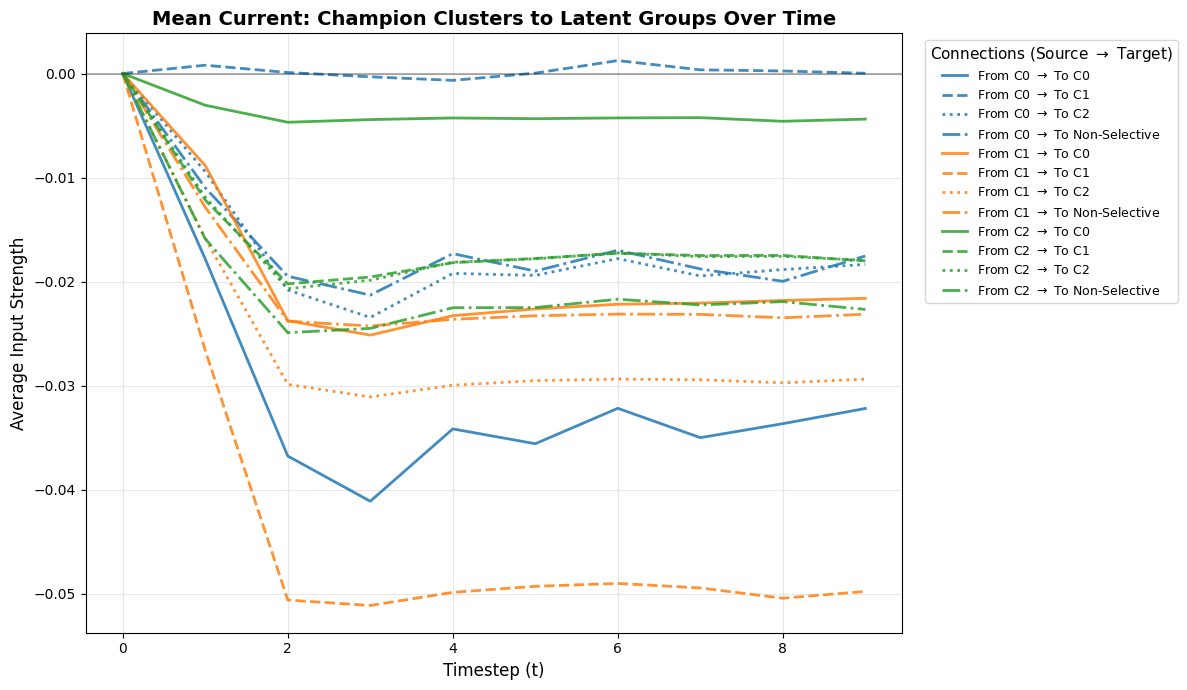

In [206]:
plot_champions_to_latents_single_plot(decomposed_data, context_to_cluster)

In [119]:
def compute_loss_when_blocking_input_after_timestep(model, loader, block_after_timestep):
    model.eval()
    val_loss = []
    with torch.no_grad():
        for val_batch in loader:
            val_imgs, val_latents, val_contexts = val_batch
            val_out = model.loss_when_blocking_input_after_timestep(val_imgs, block_after_timestep=block_after_timestep)
            loss = val_out[0]
            val_loss.append(loss.item())
    return np.mean(val_loss)


In [30]:
compute_loss_when_blocking_input_after_timestep(model, val_loader, block_after_timestep=-1)

np.float64(0.0003291630471887236)

In [31]:
loss_after_blocking = []

In [32]:
for t in range(5):
    loss = compute_loss_when_blocking_input_after_timestep(model, val_loader, block_after_timestep=t)
    print(f"Block after timestep {t}: Loss = {loss:.4f}")
    loss_after_blocking.append(loss)

Block after timestep 0: Loss = 0.0120
Block after timestep 1: Loss = 0.0113
Block after timestep 2: Loss = 0.0111
Block after timestep 3: Loss = 0.0114
Block after timestep 4: Loss = nan


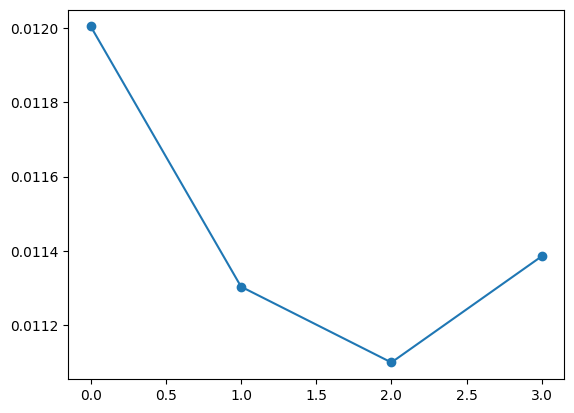

In [33]:
plt.plot(range(5), loss_after_blocking, marker='o')
